1. Carregar les dades

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the prepared bank dataset
data_path = "../../data_prepared/bank_term_deposit_prepared.csv"
df = pd.read_csv(data_path)

# Display basic structural information
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

# 2. ¡AQUÍ ESTÁ EL TRUCO! Filtrar solo las filas etiquetadas y sobreescribir 'df'
df = df[df['split'] == 'labeled'].copy()

# Eliminar la columna 'split' si ya no la necesitas para entrenar
df = df.drop(columns=['split'])

# Check target variable distribution to verify imbalance
# Assuming 'y' or 'deposit' is the target column (adjust name if different)
target_column = 'y'
print("\nTarget distribution:")
print(df[target_column].value_counts(normalize=True))

Dataset shape: (3063, 23)

First 5 rows of the dataset:
   id    split  age          job   marital  education default  balance  \
0   1  labeled   31   management   married   tertiary      no    460.0   
1   2  labeled   34  blue-collar   married  secondary      no   1826.0   
2   3  labeled   50  blue-collar   married  secondary      no    290.0   
3   4  labeled   42       admin.  divorced  secondary      no   1077.0   
4   5  labeled   47     services    single  secondary      no     41.0   

  housing loan  ... duration  campaign pdays  previous  poutcome   y  \
0      no   no  ...     13.0        14    -1         0   unknown  no   
1     yes   no  ...    203.0         2    -1         0   unknown  no   
2     yes   no  ...    226.0         3    -1         0   unknown  no   
3     yes   no  ...    213.0         1    -1         0   unknown  no   
4     yes   no  ...    298.0         1    -1         0   unknown  no   

   was_contacted_before campaign_intensity     age_group  quarter 

2. Feature Engineering

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Identify features and target
X = df.drop(columns=[target_column])

# Convert target to binary
y = df[target_column].map({
    'no': 0,
    'yes': 1
})

# Separate numerical and categorical columns
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Define preprocessing pipelines
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

C:\Users\Alumne_mati1\AppData\Local\Temp\ipykernel_13236\854003535.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


3. Train / Test Split

In [3]:
from sklearn.model_selection import train_test_split

# Define train-test split ratio (e.g., 80% train, 20% test)
test_size_ratio = 0.20
random_seed = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size_ratio,
    stratify=y,
    random_state=random_seed
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Train target ratio:\n{y_train.value_counts(normalize=True)}")

Training set shape: (1605, 21)
Testing set shape: (402, 21)
Train target ratio:
y
0    0.913396
1    0.086604
Name: proportion, dtype: float64


4. Cross-validation

In [4]:
from sklearn.model_selection import StratifiedKFold

# Define the stratified cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

# Scoring metrics to track
scoring_metrics = ['precision', 'recall', 'f1']

5. Baseline

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

# Baseline model: predicts the most frequent class
baseline_model = DummyClassifier(strategy='most_frequent')

# Evaluate baseline using cross-validation
baseline_cv_results = cross_validate(
    baseline_model, X_train, y_train,
    cv=cv_strategy, scoring=scoring_metrics, return_train_score=True
)

print(f"Baseline Train F1-Score: {baseline_cv_results['train_f1'].mean():.4f}")
print(f"Baseline Validation F1-Score: {baseline_cv_results['test_f1'].mean():.4f}")

Baseline Train F1-Score: 0.0000
Baseline Validation F1-Score: 0.0000


c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parame

6. Logistic Regression

c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Logistic Regression Params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
Best CV F1-Score: 0.7651


c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, lea

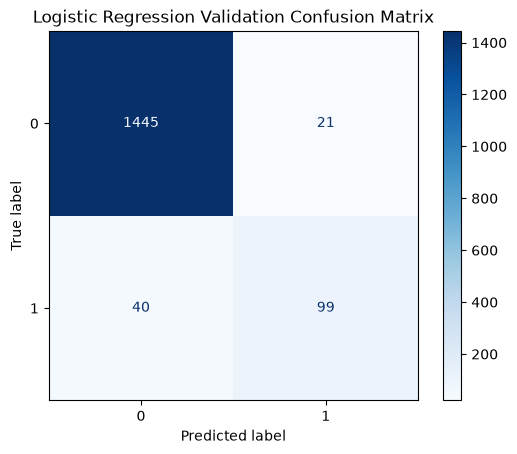

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Complete pipeline wrapping preprocessing and the model

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=random_seed))
])

# Define hyperparameter grid ensuring compatible combinations
lr_param_grid = [
    {
        'classifier__penalty': ['l2'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['lbfgs', 'saga']
    },
    {
        'classifier__penalty': ['l1'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['saga']
    }
]

# Execute Grid Search
lr_grid_search = GridSearchCV(
    lr_pipeline, param_grid=lr_param_grid,
    cv=cv_strategy, scoring='f1', return_train_score=True, n_jobs=-1
)
lr_grid_search.fit(X_train, y_train)

print(f"Best Logistic Regression Params: {lr_grid_search.best_params_}")
print(f"Best CV F1-Score: {lr_grid_search.best_score_:.4f}")

# Generate validation predictions using cross_val_predict with the best estimator
best_lr_model = lr_grid_search.best_estimator_
y_val_pred_lr = cross_val_predict(best_lr_model, X_train, y_train, cv=cv_strategy)

# Plot Confusion Matrix
cm_lr = confusion_matrix(y_train, y_val_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Validation Confusion Matrix")
plt.show()

7. Random Forest y Gradient Boosting

Best Random Forest Params: {'classifier__n_estimators': 50, 'classifier__min_samples_split': 2, 'classifier__max_depth': None}
Best CV F1-Score: 0.7415


c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


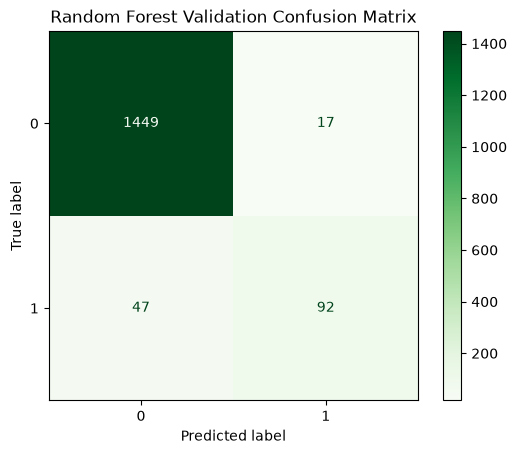

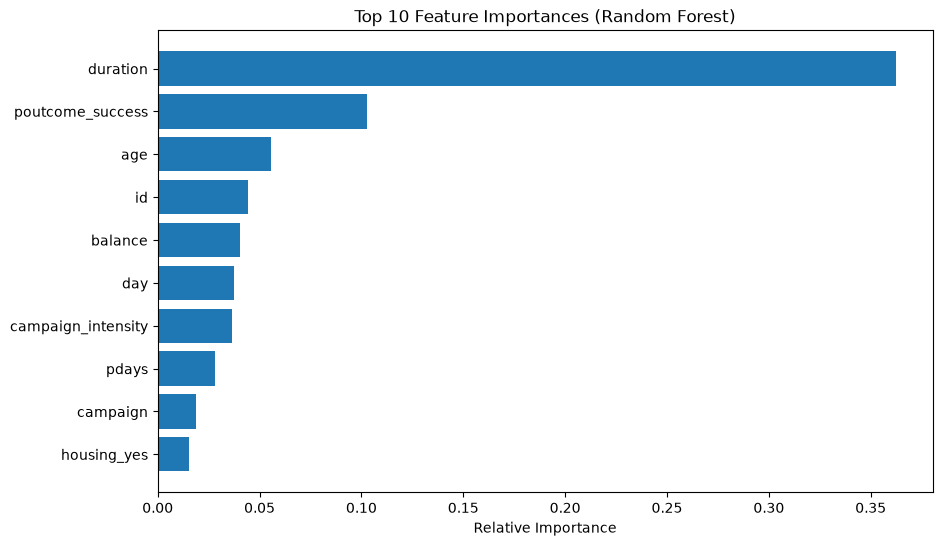

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

# 1. Definir el Pipeline de Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=random_seed))
])

# 2. Configurar el espacio de búsqueda de hiperparámetros
rf_param_dist = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

# 3. Ejecutar la búsqueda aleatoria (Randomized Search)
rf_random_search = RandomizedSearchCV(
    rf_pipeline, param_distributions=rf_param_dist, n_iter=5,
    cv=cv_strategy, scoring='f1', random_state=random_seed, n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

print(f"Best Random Forest Params: {rf_random_search.best_params_}")
print(f"Best CV F1-Score: {rf_random_search.best_score_:.4f}")


# NUEVA SECCIÓN: MATRIZ DE CONFUSIÓN PARA RANDOM FOREST

# Generar predicciones de validación cruzada "limpias" usando el mejor estimador
best_rf = rf_random_search.best_estimator_
y_val_pred_rf = cross_val_predict(best_rf, X_train, y_train, cv=cv_strategy)

# Calcular y graficar la matriz de confusión
cm_rf = confusion_matrix(y_train, y_val_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Greens) # Usamos verde para diferenciarlo de la regresión logística
plt.title("Random Forest Validation Confusion Matrix")
plt.show()


# 4. Extracción y graficación de Feature Importance (Top 10)
encoded_features = num_features + list(best_rf.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(cat_features))
importances = best_rf.named_steps['classifier'].feature_importances_

indices = np.argsort(importances)[-10:]
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [encoded_features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

8. TabPFN

Precision : 0.8571
Recall    : 0.7338
F1-score  : 0.7907

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1466
           1       0.86      0.73      0.79       139

    accuracy                           0.97      1605
   macro avg       0.92      0.86      0.89      1605
weighted avg       0.96      0.97      0.97      1605



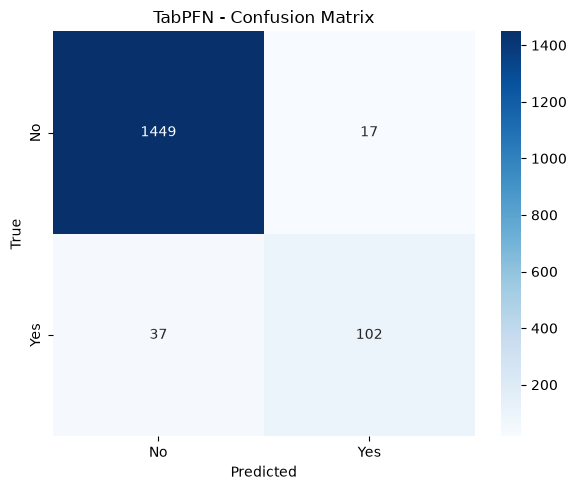

In [ ]:
# Authentication

import os

os.environ["TABPFN_TOKEN"] = "tabpfn_sk_HegmzPRECBX7B-KslW6Mxlm54tSi0dp5VkBSsBQkdMU"
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"


# 1. Imports

from tabpfn import TabPFNClassifier

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt


# 2. Prepare data


X_train_tabpfn = X_train.copy()
X_test_tabpfn = X_test.copy()

# Convert categorical columns to category dtype
for col in cat_features:
    if X_train_tabpfn[col].dtype == "object":
        X_train_tabpfn[col] = X_train_tabpfn[col].astype("category")
        X_test_tabpfn[col] = X_test_tabpfn[col].astype("category")



# 3. Create TabPFN model


tabpfn_model = TabPFNClassifier(
    device="cpu",
    random_state=random_seed,
    ignore_pretraining_limits=True
)


# 4. Cross Validation Predictions


tabpfn_cv_predictions = cross_val_predict(
    estimator=tabpfn_model,
    X=X_train_tabpfn,
    y=y_train,
    cv=cv_strategy,
    method="predict",
    n_jobs=1          # recomendado para TabPFN
)


# 5. Evaluation Metrics


precision = precision_score(
    y_train,
    tabpfn_cv_predictions,
    zero_division=0
)

recall = recall_score(
    y_train,
    tabpfn_cv_predictions,
    zero_division=0
)

f1 = f1_score(
    y_train,
    tabpfn_cv_predictions,
    zero_division=0
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(
    y_train,
    tabpfn_cv_predictions,
    zero_division=0
))


# 6. Confusion Matrix


cm = confusion_matrix(
    y_train,
    tabpfn_cv_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("TabPFN - Confusion Matrix")

plt.tight_layout()
plt.show()

9. Predicted Probabilities

c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, lea

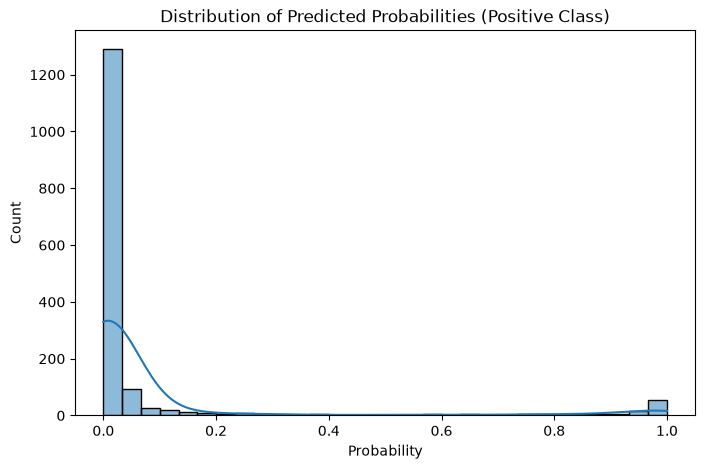

In [11]:
# Get predicted probabilities for the validation sets using Logistic Regression
y_val_proba_lr = cross_val_predict(
    best_lr_model, X_train, y_train, cv=cv_strategy, method="predict_proba"
)

# Extract probabilities for the positive class (column 1)
positive_class_probas = y_val_proba_lr[:, 1]

# Plot the distribution of probabilities to check calibration/confidence
plt.figure(figsize=(8, 5))
sns.histplot(positive_class_probas, kde=True, bins=30)
plt.title("Distribution of Predicted Probabilities (Positive Class)")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

10. Comparació final (Comparación final y Testeo)

In [12]:
from sklearn.metrics import classification_report

# Compare CV results (Example using F1-score)
print("=== FINAL REVIEWS & COMPARISONS (CV F1-SCORES) ===")
print(f"Baseline Classifier : {baseline_cv_results['test_f1'].mean():.4f}")
print(f"Logistic Regression : {lr_grid_search.best_score_:.4f}")
print(f"Random Forest       : {rf_random_search.best_score_:.4f}")

# Choose the best architecture (Assuming Random Forest performed best)
final_chosen_model = best_rf

# Evaluate on the completely untouched Test Set
y_test_pred = final_chosen_model.predict(X_test)

print("\n=== FINAL TEST SET EVALUATION ===")
print(classification_report(y_test, y_test_pred))

=== FINAL REVIEWS & COMPARISONS (CV F1-SCORES) ===
Baseline Classifier : 0.0000
Logistic Regression : 0.7651
Random Forest       : 0.7415

=== FINAL TEST SET EVALUATION ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       367
           1       0.76      0.74      0.75        35

    accuracy                           0.96       402
   macro avg       0.87      0.86      0.87       402
weighted avg       0.96      0.96      0.96       402



Testeo Final

In [ ]:
import os
import pandas as pd

# 1. Asegurar la creación de la carpeta 'predictions'
output_folder = "predictions"
os.makedirs(output_folder, exist_ok=True)

# 2. Cargar el dataset original completo (para extraer el Leaderboard)
df_complete = pd.read_csv("../../data_prepared/bank_term_deposit_prepared.csv")

# 3. Filtrar las filas destinadas al Leaderboard oficial
df_leaderboard = df_complete[df_complete['split'] == 'leaderboard'].copy()

print(f"Instancias detectadas para el Leaderboard: {df_leaderboard.shape[0]}")

# 4. Aislar las características (X) que el modelo necesita para predecir
X_leaderboard = df_leaderboard.drop(columns=['id', 'split', 'y'], errors='ignore')

# 5. Asegurar el tipo de dato de las variables categóricas para TabPFN
for col in cat_features:
    if col in X_leaderboard.columns:
        X_leaderboard[col] = X_leaderboard[col].astype("category")


# ALINEACIÓN DE COLUMNAS (Para solucionar el error de desajuste anterior)

# Eliminamos 'id' y 'split' de los datos de entrenamiento para alinearlos con X_leaderboard
X_train_final_tabpfn = X_train_tabpfn.drop(columns=['id', 'split'], errors='ignore')

# Reordenamos las columnas del leaderboard para garantizar que coincidan al 100%
X_leaderboard = X_leaderboard[X_train_final_tabpfn.columns]


# 6. Entrenar el modelo TabPFN final con todos los datos de entrenamiento alineados
print("Entrenando el modelo final TabPFN...")
tabpfn_model.fit(X_train_final_tabpfn, y_train)


# 7. Realizar las predicciones oficiales (Devuelve un array de strings: 'no' o 'yes')
print("Generando predicciones para el Leaderboard...")
leaderboard_predictions = tabpfn_model.predict(X_leaderboard)

# 8. Construir el DataFrame de salida
df_output = pd.DataFrame({
    'id': df_leaderboard['id'],
    'prediction': leaderboard_predictions
})


# SOLUCIÓN DEL RANKING: Mapeo explícito nativo de Python

# Forzamos la conversión basándonos en si el texto contiene la letra 'y' de 'yes'
# Evitamos usar .map() que es propenso a generar NaNs si hay problemas de tipos
import numpy as np
df_output['prediction'] = np.where(df_output['prediction'].astype(str).str.lower().str.contains('yes|1'), 1, 0)

# Verificación de control en consola para que tú mismo compruebes que no hay errores
print("\n[CONTROL] Distribución de tus predicciones para la competencia:")
print(df_output['prediction'].value_counts())


# 9. Guardar el archivo resultante con formato numérico
output_path = os.path.join(output_folder, "target_leaderboard_predictions.csv")
df_output.to_csv(output_path, index=False)

print(f"\n¡Proceso completado con éxito!")
print(f"Archivo guardado en: {output_path}")
print("\nPrimeras filas reales (Deben aparecer 0 y 1 distribuidos):")
print(df_output.head(15))

Instancias detectadas para el Leaderboard: 1056
Entrenando el modelo final TabPFN...
Generando predicciones para el Leaderboard...

[CONTROL] Distribución de tus predicciones para la competencia:
prediction
0    981
1     75
Name: count, dtype: int64

¡Proceso completado con éxito!
Archivo guardado en: predictions\target_leaderboard_predictions.csv

Primeras filas reales (Deben aparecer 0 y 1 distribuidos):
        id  prediction
2007  2466           0
2008  2467           0
2009  2468           0
2010  2469           1
2011  2470           0
2012  2471           0
2013  2472           0
2014  2473           0
2015  2474           0
2016  2475           0
2017  2476           0
2018  2477           0
2019  2478           0
2020  2479           0
2021  2480           0
